# Stock Price Prediction

## 1) Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.metrics import RootMeanSquaredError

In [2]:
import plotly.io as pio
pio.renderers.default = "notebook_connected+vscode+colab"

*Makes plots accessible on colab, jupyter notebook and vscode*

In [3]:
import tensorflow as tf
import os
import random

# 1. Set a single master seed value
SEED = 42
tf.random.set_seed(SEED)

# 2. Set Python core seeds
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Forces single-threaded execution to ensure GPU determinism
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# 4. Limit CPU threading randomness
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

In [4]:
df = pd.read_csv("TSLA.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,8/16/2016,45.098000,45.438000,44.681999,44.722000,44.722000,11335500
1,8/17/2016,44.866001,44.966000,44.560001,44.647999,44.647999,8935500
2,8/18/2016,44.764000,45.132000,44.458000,44.702000,44.702000,8572500
3,8/19/2016,44.708000,45.034000,44.506001,45.000000,45.000000,8297500
4,8/22/2016,44.834000,45.021999,44.535999,44.585999,44.585999,10327500
...,...,...,...,...,...,...,...
1253,8/9/2021,710.169983,719.030029,705.130005,713.760010,713.760010,14715300
1254,8/10/2021,713.989990,716.590027,701.880005,709.989990,709.989990,13432300
1255,8/11/2021,712.710022,715.179993,704.210022,707.820007,707.820007,9800600
1256,8/12/2021,706.340027,722.799988,699.400024,722.250000,722.250000,17459100


## 2) EDA

In [5]:
df = df.rename(columns={'Date': 'date','Open':'open','High':'high','Low':'low','Close':'close',
                                'Adj Close':'adj_close','Volume':'volume'})
print(df.head())

        date       open       high        low      close  adj_close    volume
0  8/16/2016  45.098000  45.438000  44.681999  44.722000  44.722000  11335500
1  8/17/2016  44.866001  44.966000  44.560001  44.647999  44.647999   8935500
2  8/18/2016  44.764000  45.132000  44.458000  44.702000  44.702000   8572500
3  8/19/2016  44.708000  45.034000  44.506001  45.000000  45.000000   8297500
4  8/22/2016  44.834000  45.021999  44.535999  44.585999  44.585999  10327500


In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       1258 non-null   object 
 1   open       1258 non-null   float64
 2   high       1258 non-null   float64
 3   low        1258 non-null   float64
 4   close      1258 non-null   float64
 5   adj_close  1258 non-null   float64
 6   volume     1258 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 68.9+ KB
None
              open         high          low        close    adj_close  \
count  1258.000000  1258.000000  1258.000000  1258.000000  1258.000000   
mean    183.274022   187.265251   178.941224   183.351102   183.351102   
std     227.979867   232.845126   222.443374   227.987027   227.987027   
min      36.220001    36.945999    35.397999    35.793999    35.793999   
25%      54.985001    55.930001    53.929001    54.994501    54.994501   
50%      66.602002    

In [7]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

In [8]:
fig= px.line(df, x='date', y='volume', title='Tesla Volume')
fig.show()

In [9]:
# 1. Ensure your date column is in datetime format
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date")

# 2. Initialize the empty figure
fig = go.Figure()

# 3. Add the Open Price line
fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["open"],
        mode="lines",
        name="Open Price",
        line=dict(color="#1f77b4") # Blue
    )
)

# 4. Add the Close Price line
fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["close"],
        mode="lines",
        name="Close Price",
        line=dict(color="#ff7f0e") # Orange
    )
)

# 5. Customize the layout with titles and a range slider
fig.update_layout(
    title="Tesla Stock Price Comparison: Open vs. Close Over Time",
    xaxis_title="Date",
    yaxis_title="Price ($)",
    hovermode="x unified", # Shows both values simultaneously when hovering
    template="plotly_white"
)

# 6. Optional: Add a range slider for easy zooming
fig.update_xaxes(rangeslider_visible=True)

# Render the interactive plot
fig.show()

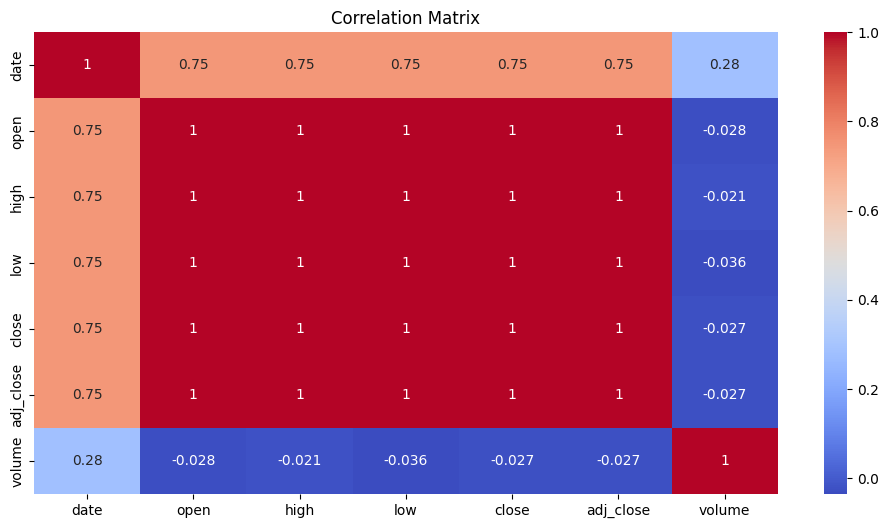

In [10]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

As you can see from the correlation matrix; adj_close, close, low, high and open price fields have a **perfect correlation** with each other (1).

This means that for the model development, we will only need ONE of these "price" features for the time series forecasting model.

We'll be predicting the **"close"** price for the stock, so that's the feature we'll use. Along with that, we'll use volumne as the other feature to use for predicting "close".

## 3) Train Set preparation for LSTM

In [11]:
# Prepare for the LSTM Model (Sequential)
# Using 'close' and 'volume' as features for better prediction
stock_features = df[["close", "volume"]]
dataset = stock_features.values
training_data_len = int(np.ceil(len(dataset) * 0.8))

In [12]:
# Preprocessing Stages - Scale the data
# Using MinMaxScaler as it's often preferred for LSTM with stock prices
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset) # dataset now has multiple columns

In [13]:
training_data = scaled_data[:training_data_len]
x_train,y_train = [],[]

In [14]:
# Create a sliding window for our stock (60 days)
# x_train will now have 'close' and 'volume' for each time step
# y_train will predict the 'close' price (first feature)
for i in range(60, len(training_data)):
    x_train.append(training_data[i-60:i, :]) # Use all features
    y_train.append(training_data[i, 0])      # Predict only the 'close' price (first feature)

x_train, y_train = np.array(x_train), np.array(y_train)

In [15]:
# Reshape for LSTM: [samples, time_steps, features]
# x_train is already in the correct shape (samples, time_steps, features) if `x_train.append(training_data[i-60:i, :])` was used.
# Verify shape: (num_samples, 60, num_features)
print(f"x_train shape after processing: {x_train.shape}")

x_train shape after processing: (947, 60, 2)


## 4) LSTM (Long short-term memory) ~ RNN {Recurrent Neural Network)

In [16]:
# Use a specific initializer with a set seed
initializer = tf.keras.initializers.GlorotUniform(seed=SEED)

# Build the Model
model = Sequential()

# First Layer
model.add(LSTM(64,kernel_initializer=initializer, recurrent_initializer=initializer,return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))

# Second Layer
model.add(LSTM(128,kernel_initializer=initializer, recurrent_initializer=initializer,return_sequences=False))

# Third Layer
model.add(Dense(64,kernel_initializer=initializer,activation='relu'))

# Fourth Layer
model.add(Dropout(0.3,seed=SEED))

#Final Output Layer
model.add(Dense(1,kernel_initializer=initializer))

model.summary()
model.compile(optimizer='adam',
              loss='mae',
              metrics=[RootMeanSquaredError()])

training = model.fit(x_train, y_train, batch_size=32, epochs=20, shuffle=SEED)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,289 (485.50 KB)

 Trainable params: 124,289 (485.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0186 - root_mean_squared_error: 0.0366
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0111 - root_mean_squared_error: 0.0194
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0093 - root_mean_squared_error: 0.0161
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.0084 - root_mean_squared_error: 0.0144
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0084 - root_mean_squared_error: 0.0153
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0084 - root_mean_squared_error: 0.0150
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0079 - root_mean_squared_error: 0.0148
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - loss: 0.0078 - root_mean_squared_error: 0.0138
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0074 - root_mean_squared_error: 0.0130
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0081 - root_mean_squared_error: 0.01

In [17]:
# Prep the test data
test_data = scaled_data[training_data_len - 60:]
x_test = []
y_test_actual = dataset[training_data_len:] # Keep original unscaled data for y_test

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, :]) # Use all features for x_test

x_test = np.array(x_test)
# x_test is already in the correct shape (samples, time_steps, features)
print(f"x_test shape after processing: {x_test.shape}")

x_test shape after processing: (251, 60, 2)


In [18]:
# Make a Prediction
predictions = model.predict(x_test)

# The scaler was fitted on 2 features ('close' and 'volume').
# To inverse_transform, we need an input with 2 columns.
# Create a dummy array with the same number of rows as predictions and 2 columns.
predictions_extended = np.zeros((predictions.shape[0], dataset.shape[1]))

# Place the 'close' price predictions (first feature) into the first column of the dummy array
predictions_extended[:, 0] = predictions[:, 0]

# Inverse transform the extended predictions array
predictions_unscaled = scaler.inverse_transform(predictions_extended)

# Extract only the 'close' price predictions (the first column) from the unscaled data
predictions = predictions_unscaled[:, 0]

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


In [19]:
# Plotting Data
train = df.loc[:training_data_len]
test = df.loc[training_data_len:].copy()

test['Predictions'] = predictions

# Initialize the figure
fig = go.Figure()

# Add the Train trace
fig.add_trace(go.Scatter(x=train['date'], y=train['close'],
                         mode='lines', name='Train (Actual)',
                         line=dict(color='blue')))

# Add the Test trace
fig.add_trace(go.Scatter(x=test['date'], y=test['close'],
                         mode='lines', name='Test (Actual)',
                         line=dict(color='orange')))

# Add the Predictions trace
fig.add_trace(go.Scatter(x=test['date'], y=test['Predictions'],
                         mode='lines', name='Predictions',
                         line=dict(color='red')))

# Update layout to include the range slider and labels
fig.update_layout(
    title='Tesla Stock Price Prediction',
    xaxis_title='Date',
    yaxis_title='Close Price ($)',
    xaxis=dict(
        rangeslider=dict(visible=True),
        type="date"
    ),
    hovermode="x unified", # Shows both values simultaneously when hovering
    template="plotly_white"
)

fig.show()

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error
import numpy as np

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test['close'], predictions))

# Calculate MAE (Mean Absolute Error)
mae = mean_absolute_error(test['close'], predictions)

# Calculate MAPE (Mean Abslute Percentage Error)
mape = mean_absolute_percentage_error(test['close'], predictions)

print(f"Root Mean Squared Error: ${rmse:.2f}")
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Mean Absolute Percentage Error: {mape:.2%}")

Root Mean Squared Error: $43.20
Mean Absolute Error: $33.84
Mean Absolute Percentage Error: 5.45%


### 5) Summary and Considerations:
- The MAE and RMSE are low enough and the MAPE is **5.45%**, shows that the model is very good at predicting the stock price
